## Machine Learning 1
### Ingeniería Electrónica 

**Semana 3 y 4: Preprocesamiento de Datos Granular, Imputación, Detección y Verificación de Outliers en Validación (Tabulares e Imágenes)** 

---

El preprocesamiento rigoroso de datos es la base del aprendizaje automático. En esta práctica abordaremos la limpieza, imputación y detección de observaciones atípicas (*outliers*) tanto en datos **tabulares** como en **imágenes reales** (utilizando el repositorio Olivetti Faces).

Para evitar el **fuga de datos (*data leakage*)**, realizaremos previamente una partición en conjuntos de **Entrenamiento (*Train*)** y **Validación/Prueba (*Test*)**, ajustando los transformadores y detectores únicamente en el conjunto de entrenamiento y verificando cuantitativamente la calidad de la detección mediante métricas de evaluación ($Precision, Recall, F_1-Score$).

## 1. Fuentes de Datos y Adquisición Automatizada desde Internet

Fundamentación matemática de ausencia de datos:
- **MCAR** (*Missing Completely at Random*): $P(M | Y_{obs}, Y_{mis}) = P(M)$
- **MAR** (*Missing at Random*): $P(M | Y_{obs}, Y_{mis}) = P(M | Y_{obs})$
- **MNAR** (*Missing Not at Random*): $P(M | Y_{obs}, Y_{mis}) = P(M | Y_{obs}, Y_{mis})$

| Dataset / Fuente | Tipo de Datos | Tarea de ML | Retos de Limpieza |
| :--- | :--- | :--- | :--- |
| **[Titanic Open Dataset](https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv)** | Tabular (CSV) | Clasificación Supervisada | Nulos en `Age`, `Cabin`, `Embarked` y outliers en `Fare`. |
| **[Olivetti Real Faces Dataset](https://scikit-learn.org/stable/datasets/real_world.html#olivetti-faces-dataset)** | Imágenes Reales ($64 \times 64$ px) | Visión / Anomaly Detection | Rostros humanos reales del laboratorio AT&T Cambridge con anomalías físicas/ópticas inyectadas. |

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy import stats
from scipy.ndimage import laplace
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.datasets import fetch_olivetti_faces
from IPython.display import display

# Estilo global de Matplotlib
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

In [20]:
def download_csv_dataset(url: str) -> pd.DataFrame:
    """Descarga un dataset CSV desde una URL pública."""
    print(f"Descargando datos desde: {url} ...")
    df = pd.read_csv(url)
    print(f"Dataset cargado con éxito. Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas.")
    return df

url_titanic = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_raw = download_csv_dataset(url_titanic)

Descargando datos desde: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv ...
Dataset cargado con éxito. Dimensiones: 891 filas x 12 columnas.


In [21]:
def inspect_data_quality(df: pd.DataFrame):
    """Muestra métricas de nulos y tipos de datos."""
    summary_df = pd.DataFrame({
        'Tipo_Dato': df.dtypes.astype(str),
        'Valores_Nulos': df.isnull().sum(),
        'Porcentaje_Nulos (%)': (df.isnull().sum() / len(df) * 100).round(2),
        'Valores_Unicos': df.nunique()
    })
    print("\n--- RESUMEN DE ESTRUCTURA Y CALIDAD DE DATOS ---")
    display(summary_df)

inspect_data_quality(df_raw)


--- RESUMEN DE ESTRUCTURA Y CALIDAD DE DATOS ---


,Tipo_Dato,Valores_Nulos,Porcentaje_Nulos (%),Valores_Unicos
PassengerId,int64,0,0.00,891
Survived,int64,0,0.00,2
Pclass,int64,0,0.00,3
Name,str,0,0.00,891
Sex,str,0,0.00,2
Age,float64,177,19.87,88
SibSp,int64,0,0.00,7
Parch,int64,0,0.00,7
Ticket,str,0,0.00,681
Fare,float64,0,0.00,248


## 2. Limpieza de Datos Tabulares e Imputación Faltante

Formulaciones Matemáticas de Imputación:
- **Media Univariada**: $\bar{x} = \frac{1}{N_{obs}} \sum_{i \in Obs} x_i$
- **Mediana Univariada**: $Med(X) = P_{50}(X)$
- **Distancia Euclídea en KNN Imputer**: $d(x, p) = \sqrt{\sum_{k=1}^m w_k (x_k - p_k)^2}$

Para evitar la fuga de información (*Data Leakage*), dividiremos primero en conjunto de **Train** y **Validation/Test** antes de imputar.

In [22]:
# Partición de datos en Train (80%) y Validation/Test (20%)
df_train, df_test = train_test_split(df_raw, test_size=0.20, random_state=42)
print(f"Tamaño Conjunto de Entrenamiento (Train): {df_train.shape[0]} filas")
print(f"Tamaño Conjunto de Validación/Test (Test):   {df_test.shape[0]} filas")

Tamaño Conjunto de Entrenamiento (Train): 712 filas
Tamaño Conjunto de Validación/Test (Test):   179 filas


In [23]:
def preprocess_tabular_features(df_tr: pd.DataFrame, df_te: pd.DataFrame) -> tuple:
    """Aplica imputación entrenando transformadores SOLO en Train y transformando Test."""
    tr = df_tr.copy()
    te = df_te.copy()
    
    # 1. Eliminación de duplicados en Train
    tr = tr.drop_duplicates()
    
    # 2. Variable indicadora Has_Cabin y remoción de alta cardinalidad
    for d in [tr, te]:
        d['Has_Cabin'] = d['Cabin'].notnull().astype(int)
        d.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'], inplace=True, errors='ignore')
        
    # 3. Imputación Categórica por Moda
    imp_cat = SimpleImputer(strategy='most_frequent')
    tr['Embarked'] = imp_cat.fit_transform(tr[['Embarked']]).ravel()
    te['Embarked'] = imp_cat.transform(te[['Embarked']]).ravel()
    
    # 4. Imputación Numérica KNN
    num_cols = ['Pclass', 'SibSp', 'Parch', 'Fare', 'Age']
    knn_imp = KNNImputer(n_neighbors=5)
    
    tr[num_cols] = knn_imp.fit_transform(tr[num_cols])
    te[num_cols] = knn_imp.transform(te[num_cols])
    
    return tr, te

df_train_clean, df_test_clean = preprocess_tabular_features(df_train, df_test)
print("Imputación completada sin Data Leakage.")

Imputación completada sin Data Leakage.


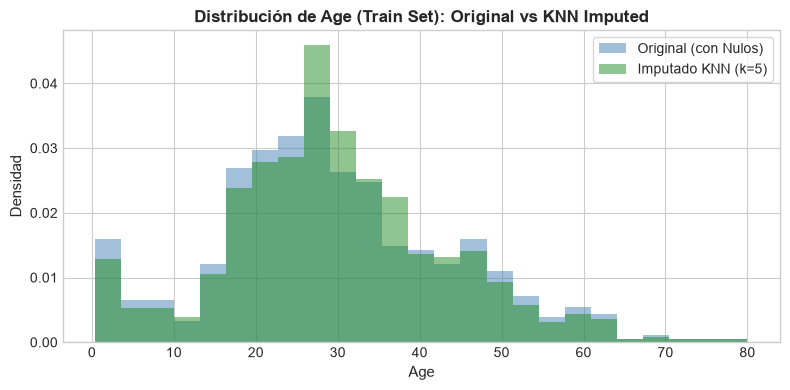

In [24]:
def plot_imputation_results(df_orig: pd.DataFrame, df_clean: pd.DataFrame, var_name: str):
    """Grafica la distribución de la variable imputada en Matplotlib."""
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(df_orig[var_name].dropna(), bins=25, alpha=0.5, color='steelblue', label='Original (con Nulos)', density=True)
    ax.hist(df_clean[var_name], bins=25, alpha=0.5, color='forestgreen', label='Imputado KNN (k=5)', density=True)
    ax.set_title(f'Distribución de {var_name} (Train Set): Original vs KNN Imputed', fontweight='bold')
    ax.set_xlabel(var_name)
    ax.set_ylabel('Densidad')
    ax.legend(frameon=True)
    plt.tight_layout()
    plt.show()

plot_imputation_results(df_train, df_train_clean, 'Age')

## 3. Identificación y Verificación de Outliers Numéricos

Formulaciones Matemáticas de Detección de Outliers:
- **Z-Score Normalizado**: $Z_i = \frac{x_i - \mu}{\sigma}, \quad \text{Outlier si } |Z_i| > 3$
- **Rango Intercuartílico (IQR)**: $IQR = Q_3 - Q_1$
  $$\text{Límite Inferior} = Q_1 - 1.5 \cdot IQR, \quad \text{Límite Superior} = Q_3 + 1.5 \cdot IQR$$
- **Score de Isolation Forest**: $s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}$ donde $h(x)$ es la longitud del camino de aislamiento y $c(n)$ es la longitud media de camino no exitoso en un árbol BST.

In [25]:
def fit_outlier_detectors(df_tr: pd.DataFrame, target_col: str) -> dict:
    """Calcula parámetros de outliers en Train."""
    # IQR en Train
    Q1 = df_tr[target_col].quantile(0.25)
    Q3 = df_tr[target_col].quantile(0.75)
    IQR = Q3 - Q1
    upper_b = Q3 + 1.5 * IQR
    lower_b = Q1 - 1.5 * IQR
    
    # Isolation Forest en Train
    iso = IsolationForest(contamination=0.05, random_state=42)
    iso.fit(df_tr[['Age', 'Fare', 'SibSp', 'Parch']])
    
    return {
        'upper_bound': upper_b,
        'lower_bound': lower_b,
        'iso_model': iso
    }

outlier_params = fit_outlier_detectors(df_train_clean, 'Fare')
print(f"Límite Superior IQR (calculado en Train): ${outlier_params['upper_bound']:.2f}")

Límite Superior IQR (calculado en Train): $64.36


In [26]:
def predict_and_verify_outliers(df: pd.DataFrame, params: dict, target_col: str, set_name: str) -> pd.DataFrame:
    """Aplica parámetros de IQR e Isolation Forest a un conjunto de datos (Train o Test)."""
    res = df.copy()
    res['Outlier_IQR'] = (res[target_col] < params['lower_bound']) | (res[target_col] > params['upper_bound'])
    
    iso_preds = params['iso_model'].predict(res[['Age', 'Fare', 'SibSp', 'Parch']])
    res['Outlier_Iso'] = (iso_preds == -1)
    
    print(f"\n--- RESULTADOS DE DETECCIÓN DE OUTLIERS EN CONJUNTO {set_name.upper()} ---")
    print(f"Total Registros: {len(res)}")
    print(f"Outliers detectados por IQR en '{target_col}': {res['Outlier_IQR'].sum()} ({(res['Outlier_IQR'].sum()/len(res)*100):.2f}%)")
    print(f"Outliers detectados por Isolation Forest:     {res['Outlier_Iso'].sum()} ({(res['Outlier_Iso'].sum()/len(res)*100):.2f}%)")
    return res

df_train_out = predict_and_verify_outliers(df_train_clean, outlier_params, 'Fare', 'Train')
df_test_out  = predict_and_verify_outliers(df_test_clean, outlier_params, 'Fare', 'Validation/Test')


--- RESULTADOS DE DETECCIÓN DE OUTLIERS EN CONJUNTO TRAIN ---
Total Registros: 712
Outliers detectados por IQR en 'Fare': 96 (13.48%)
Outliers detectados por Isolation Forest:     36 (5.06%)

--- RESULTADOS DE DETECCIÓN DE OUTLIERS EN CONJUNTO VALIDATION/TEST ---
Total Registros: 179
Outliers detectados por IQR en 'Fare': 22 (12.29%)
Outliers detectados por Isolation Forest:     5 (2.79%)


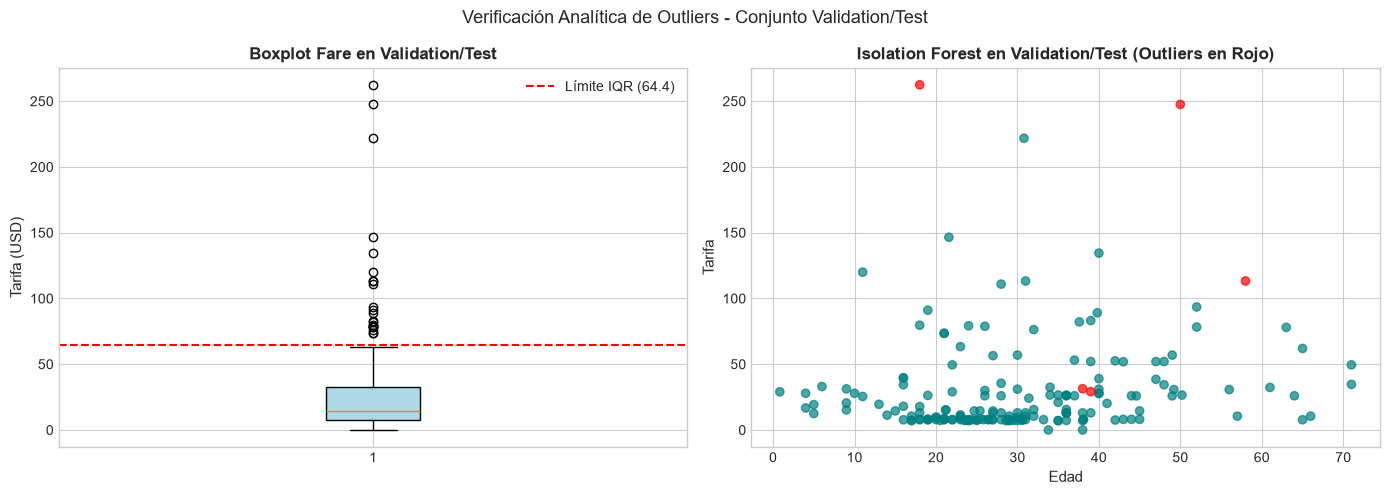

In [27]:
def plot_outliers_dashboard(df: pd.DataFrame, params: dict, set_name: str):
    """Grafica el comportamiento de los outliers en el conjunto seleccionado con Matplotlib."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Boxplot Fare
    axes[0].boxplot(df['Fare'], patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[0].axhline(params['upper_bound'], color='red', linestyle='--', label=f'Límite IQR ({params["upper_bound"]:.1f})')
    axes[0].set_title(f'Boxplot Fare en {set_name}', fontweight='bold')
    axes[0].set_ylabel('Tarifa (USD)')
    axes[0].legend()
    
    # 2. Scatter Isolation Forest
    colors = np.where(df['Outlier_Iso'], 'red', 'teal')
    axes[1].scatter(df['Age'], df['Fare'], c=colors, alpha=0.7)
    axes[1].set_title(f'Isolation Forest en {set_name} (Outliers en Rojo)', fontweight='bold')
    axes[1].set_xlabel('Edad')
    axes[1].set_ylabel('Tarifa')
    
    plt.suptitle(f'Verificación Analítica de Outliers - Conjunto {set_name}', fontsize=13)
    plt.tight_layout()
    plt.show()

plot_outliers_dashboard(df_test_out, outlier_params, 'Validation/Test')

## 4. Análisis y Metadatos de Imágenes Reales

Formulaciones Matemáticas de Metadatos Físicos de Imágenes:
- **Brillo Medio ($\mu_I$)**: $\mu_I = \frac{1}{H \times W} \sum_{x=1}^W \sum_{y=1}^H I(x,y)$
- **Desviación Estándar ($\sigma_I$, Contraste)**: $\sigma_I = \sqrt{\frac{1}{H \times W} \sum_{x=1}^W \sum_{y=1}^H (I(x,y) - \mu_I)^2}$
- **Varianza del Laplaciano (Nitidez/Enfoque)**: $\text{Blur Score} = Var(\nabla^2 I)$
  donde $\nabla^2 I = \frac{\partial^2 I}{\partial x^2} + \frac{\partial^2 I}{\partial y^2}$ mediante el kernel de convolución $\begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix}$.

In [28]:
def load_real_image_dataset_with_ground_truth(n_samples: int = 120) -> tuple:
    """Carga imágenes reales de rostros (Olivetti Faces) e inyecta anomalías etiquetadas (Ground Truth)."""
    dataset = fetch_olivetti_faces(shuffle=True, random_state=42)
    raw_faces = (dataset.images[:n_samples] * 255).astype(np.uint8)
    
    images = []
    labels_gt = [] # 0: Normal, 1: Outlier
    status_list = []
    
    for i in range(len(raw_faces)):
        img = raw_faces[i].copy()
        h, w = img.shape
        is_outlier = 0
        status = "Normal (Rostro Real)"
        
        # Inyección de anomalías controladas
        if i in [10, 25, 50, 75, 95]:
            is_outlier = 1
            if i == 10:
                img = np.random.randint(0, 5, (h, w), dtype=np.uint8) # Pitch Black
                status = "Outlier (Subexpuesta / Pitch Black)"
            elif i == 25:
                img = np.random.randint(250, 256, (h, w), dtype=np.uint8) # Saturada Blanco
                status = "Outlier (Sobreexpuesta / Saturada)"
            elif i == 50:
                noise = np.random.randint(0, 256, (h, w), dtype=np.uint8) # Estática Sal y Pimienta
                mask = np.random.rand(h, w) > 0.5
                img = np.where(mask, img, noise)
                status = "Outlier (Ruido Masivo Estática)"
            elif i in [75, 95]:
                img = 255 - img # Inversión Anómala
                status = "Outlier (Inversión Anómala)"
                
        images.append(img)
        labels_gt.append(is_outlier)
        status_list.append(status)
        
    return images, np.array(labels_gt), status_list

imgs_all, y_gt_all, status_all = load_real_image_dataset_with_ground_truth(120)
print(f"Dataset de Imágenes Reales Cargado: {len(imgs_all)} imágenes total ({y_gt_all.sum()} outliers etiquetados).")

Dataset de Imágenes Reales Cargado: 120 imágenes total (5 outliers etiquetados).


In [29]:
def extract_image_metadata_df(images: list, labels_gt: np.ndarray, status_list: list) -> pd.DataFrame:
    """Extrae metadatos físicos de cada imagen."""
    meta = []
    for i in range(len(images)):
        img = images[i]
        h, w = img.shape
        blur_val = laplace(img).var()
        meta.append({
            'Image_ID': f"face_{i:03d}",
            'Height': h,
            'Width': w,
            'Aspect_Ratio': round(w / h, 2),
            'Mean_Brightness': round(img.mean(), 2),
            'Std_Brightness': round(img.std(), 2),
            'Blur_Score': round(blur_val, 2),
            'Ground_Truth_Outlier': labels_gt[i],
            'Status': status_list[i]
        })
    return pd.DataFrame(meta)

df_image_meta = extract_image_metadata_df(imgs_all, y_gt_all, status_all)
display(df_image_meta.head(8))

,Image_ID,Height,Width,Aspect_Ratio,Mean_Brightness,Std_Brightness,Blur_Score,Ground_Truth_Outlier,Status
0,face_000,64,64,1.0,128.81,35.85,13531.01,0,Normal (Rostro Real)
1,face_001,64,64,1.0,108.35,31.12,14047.61,0,Normal (Rostro Real)
2,face_002,64,64,1.0,153.95,36.03,13635.48,0,Normal (Rostro Real)
3,face_003,64,64,1.0,99.79,33.55,12231.06,0,Normal (Rostro Real)
4,face_004,64,64,1.0,129.51,55.79,13300.82,0,Normal (Rostro Real)
5,face_005,64,64,1.0,142.73,40.38,13454.62,0,Normal (Rostro Real)
6,face_006,64,64,1.0,111.47,34.38,13215.85,0,Normal (Rostro Real)
7,face_007,64,64,1.0,149.50,52.15,13039.80,0,Normal (Rostro Real)


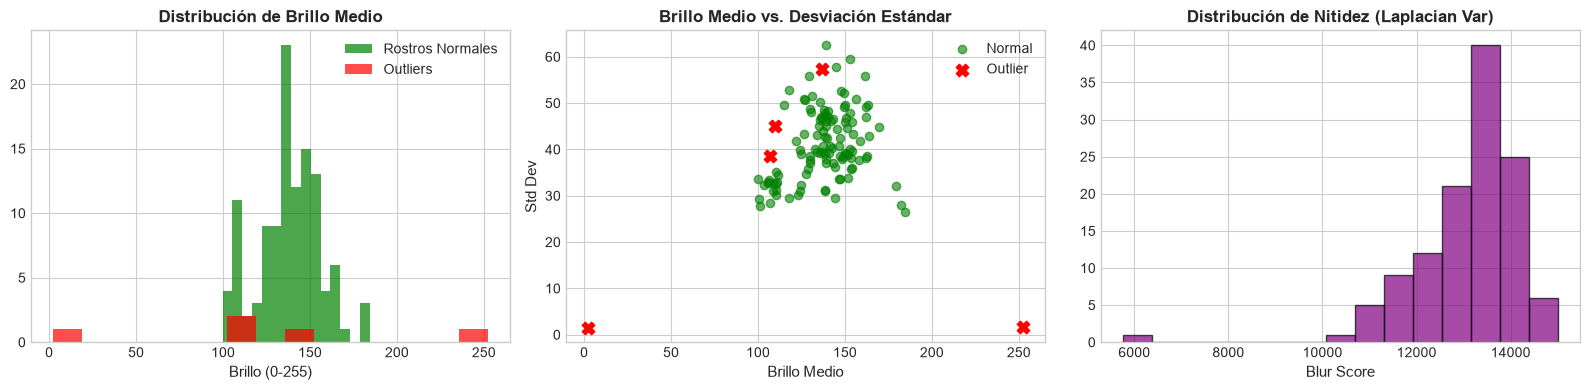

In [30]:
def plot_image_metadata_dashboard(df_meta: pd.DataFrame):
    """Grafica la distribución de metadatos de las imágenes reales."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    # 1. Brillo Medio
    axes[0].hist(df_meta[df_meta['Ground_Truth_Outlier']==0]['Mean_Brightness'], bins=15, alpha=0.7, color='green', label='Rostros Normales')
    axes[0].hist(df_meta[df_meta['Ground_Truth_Outlier']==1]['Mean_Brightness'], bins=15, alpha=0.7, color='red', label='Outliers')
    axes[0].set_title('Distribución de Brillo Medio', fontweight='bold')
    axes[0].set_xlabel('Brillo (0-255)')
    axes[0].legend()
    
    # 2. Scatter Brillo vs Contraste
    axes[1].scatter(df_meta[df_meta['Ground_Truth_Outlier']==0]['Mean_Brightness'], df_meta[df_meta['Ground_Truth_Outlier']==0]['Std_Brightness'], color='green', label='Normal', alpha=0.6)
    axes[1].scatter(df_meta[df_meta['Ground_Truth_Outlier']==1]['Mean_Brightness'], df_meta[df_meta['Ground_Truth_Outlier']==1]['Std_Brightness'], color='red', label='Outlier', marker='X', s=80)
    axes[1].set_title('Brillo Medio vs. Desviación Estándar', fontweight='bold')
    axes[1].set_xlabel('Brillo Medio')
    axes[1].set_ylabel('Std Dev')
    axes[1].legend()
    
    # 3. Blur Score
    axes[2].hist(df_meta['Blur_Score'], bins=15, color='purple', alpha=0.7, edgecolor='black')
    axes[2].set_title('Distribución de Nitidez (Laplacian Var)', fontweight='bold')
    axes[2].set_xlabel('Blur Score')
    
    plt.tight_layout()
    plt.show()

plot_image_metadata_dashboard(df_image_meta)

## 5. Reducción de Dimensionalidad con PCA y Verificación cuantitativa en Test

Formulaciones Matemáticas de PCA / Eigenfaces y Reconstrucción:
- **Matriz de Covarianza**: $\Sigma = \frac{1}{N-1} X^T X \quad \text{con } X \in \mathbb{R}^{N \times D}$
- **Autovalores y Autovectores (Eigenfaces)**: $\Sigma v_k = \lambda_k v_k$
- **Proyección al Espacio Latente ($K$ componentes)**: $Z = X V_K \in \mathbb{R}^{N \times K}$
- **Reconstrucción de Imagen**: $\hat{X} = Z V_K^T \in \mathbb{R}^{N \times D}$
- **Error de Reconstrucción (MSE)**: $e_i = \frac{1}{D} \|x_i - \hat{x}_i\|_2^2 = \frac{1}{D} \sum_{j=1}^D (x_{i,j} - \hat{x}_{i,j})^2$

Métricas Matemáticas de Verificación Cuantitativa:
- **Precisión**: $Precision = \frac{TP}{TP + FP}$
- **Exhaustividad (Recall)**: $Recall = \frac{TP}{TP + FN}$
- **Valor $F_1$**: $F_1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$

In [31]:
# Partición de imágenes en Train (80%) y Validation/Test (20%) preservando etiquetas Ground Truth
X_img_all = np.array([img.flatten() for img in imgs_all])

X_img_tr, X_img_te, y_gt_tr, y_gt_te, idx_tr, idx_te = train_test_split(
    X_img_all, y_gt_all, range(len(imgs_all)), test_size=0.20, random_state=42, stratify=y_gt_all
)

print(f"Rostros en Entrenamieto (Train): {len(X_img_tr)} imágenes ({y_gt_tr.sum()} outliers etiquetados)")
print(f"Rostros en Validación (Test):   {len(X_img_te)} imágenes ({y_gt_te.sum()} outliers etiquetados)")

Rostros en Entrenamieto (Train): 96 imágenes (4 outliers etiquetados)
Rostros en Validación (Test):   24 imágenes (1 outliers etiquetados)


In [32]:
def fit_pca_image_outlier_detector(X_train: np.ndarray, y_train_gt: np.ndarray, n_components: int = 15) -> tuple:
    """Entrena StandardScaler y PCA utilizando preferentemente muestras normales de Train."""
    # Filtramos para entrenar el modelo de rostros principalmente con muestras normales de Train
    X_train_normal = X_train[y_train_gt == 0]
    
    scaler = StandardScaler()
    X_tr_scaled_normal = scaler.fit_transform(X_train_normal)
    
    pca = PCA(n_components=n_components, random_state=42)
    pca.fit(X_tr_scaled_normal)
    
    # Calculamos errores de reconstrucción en Train para establecer el umbral óptimo
    X_tr_scaled_all = scaler.transform(X_train)
    X_tr_rec = pca.inverse_transform(pca.transform(X_tr_scaled_all))
    mse_tr = np.mean(np.square(X_tr_scaled_all - X_tr_rec), axis=1)
    
    # Umbral derivado del conjunto de Train
    threshold = np.mean(mse_tr[y_train_gt == 0]) + 2.5 * np.std(mse_tr[y_train_gt == 0])
    
    return scaler, pca, threshold

scaler_pca, pca_model, pca_threshold = fit_pca_image_outlier_detector(X_img_tr, y_gt_tr, n_components=15)
print(f"Modelo PCA (Eigenfaces) entrenado en Train. Umbral MSE derivado: {pca_threshold:.4f}")

Modelo PCA (Eigenfaces) entrenado en Train. Umbral MSE derivado: 0.3716


In [33]:
def evaluate_pca_outlier_predictions(scaler, pca, threshold, X_data, y_true_gt, set_name="Validation/Test") -> np.ndarray:
    """Aplica el modelo PCA ajustado y verifica cuantitativamente el desempeño en Test."""
    X_scaled = scaler.transform(X_data)
    X_rec = pca.inverse_transform(pca.transform(X_scaled))
    mse_errors = np.mean(np.square(X_scaled - X_rec), axis=1)
    
    y_pred_outliers = (mse_errors > threshold).astype(int)
    
    prec, rec, f1, _ = precision_recall_fscore_support(y_true_gt, y_pred_outliers, average='binary', zero_division=0)
    cm = confusion_matrix(y_true_gt, y_pred_outliers)
    
    print(f"\n================ VERIFICACIÓN CUANTITATIVA EN {set_name.upper()} ================")
    print(f"Matriz de Confusión:\n{cm}")
    print(f"Precisión (Precision):  {prec:.4f}")
    print(f"Exhaustividad (Recall): {rec:.4f}")
    print(f"Puntaje F1 (F1-Score):   {f1:.4f}")
    
    return y_pred_outliers, mse_errors

y_pred_te, mse_test = evaluate_pca_outlier_predictions(scaler_pca, pca_model, pca_threshold, X_img_te, y_gt_te, "Validation/Test")


================ VERIFICACIÓN CUANTITATIVA EN VALIDATION/TEST ================
Matriz de Confusión:
[[18  5]
 [ 0  1]]
Precisión (Precision):  0.1667
Exhaustividad (Recall): 1.0000
Puntaje F1 (F1-Score):   0.2857


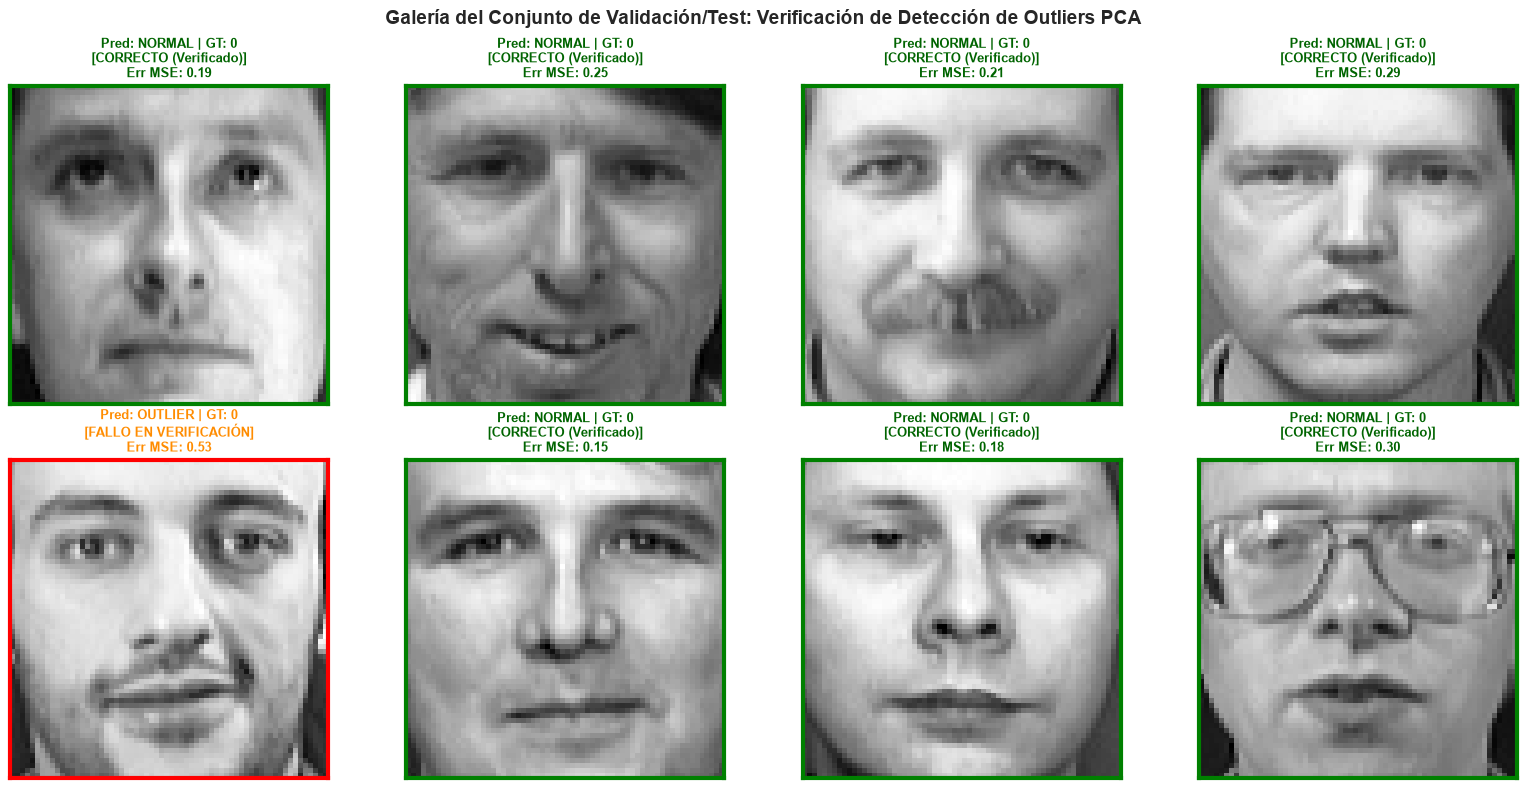

In [34]:
def plot_verified_image_outlier_gallery(imgs_all: list, idx_test: list, y_gt_te: np.ndarray, y_pred_te: np.ndarray, mse_test: np.ndarray):
    """Muestra la galería de imágenes del conjunto de validación indicando la verificación real."""
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('Galería del Conjunto de Validación/Test: Verificación de Detección de Outliers PCA', fontsize=14, fontweight='bold')
    
    for i in range(min(8, len(idx_test))):
        row = i // 4
        col = i % 4
        orig_idx = idx_test[i]
        img = imgs_all[orig_idx]
        
        gt = y_gt_te[i]
        pred = y_pred_te[i]
        err = mse_test[i]
        
        ax = axes[row, col]
        ax.imshow(img, cmap='gray')
        
        # Verificación: ¿Se identificó apropiadamente?
        if gt == pred:
            match_status = "CORRECTO (Verificado)"
            color = 'darkgreen' if gt == 0 else 'crimson'
        else:
            match_status = "FALLO EN VERIFICACIÓN"
            color = 'darkorange'
            
        label_text = "OUTLIER" if pred == 1 else "NORMAL"
        ax.set_title(f"Pred: {label_text} | GT: {gt}\n[{match_status}]\nErr MSE: {err:.2f}", color=color, fontweight='bold', fontsize=9)
        
        border_color = 'red' if pred == 1 else 'green'
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3)
            
        ax.set_xticks([])
        ax.set_yticks([])
        
    plt.tight_layout()
    plt.show()

plot_verified_image_outlier_gallery(imgs_all, idx_te, y_gt_te, y_pred_te, mse_test)

## 6. Encapsulamiento en Pipeline de Producción

En producción, la imputación y normalización continua se integran mediante `ColumnTransformer` para garantizar reproducibilidad.

In [35]:
def build_production_pipeline(num_features: list, cat_features: list) -> ColumnTransformer:
    """Crea un ColumnTransformer de Scikit-Learn."""
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ])
    return ColumnTransformer([
        ('num', num_pipe, num_features),
        ('cat', cat_pipe, cat_features)
    ])

num_cols = ['Age', 'Fare', 'SibSp', 'Parch']
cat_cols = ['Sex', 'Pclass', 'Embarked']

pipeline = build_production_pipeline(num_cols, cat_cols)
X_tr_proc = pipeline.fit_transform(df_train_raw if 'df_train_raw' in locals() else df_train)
X_te_proc = pipeline.transform(df_test_raw if 'df_test_raw' in locals() else df_test)

print(f"Matriz de entrenamiento procesada: {X_tr_proc.shape}")
print(f"Matriz de validación procesada:    {X_te_proc.shape}")

Matriz de entrenamiento procesada: (712, 9)
Matriz de validación procesada:    (179, 9)


## Resumen Pedagógico y Lista de Cotejo

1. **Granularidad y Modularidad**: Dividir el código en funciones independientes y celdas pequeñas y enfocadas.
2. **Formulación Matemática**: Incluir ecuaciones formales de imputación, distancia, Z-Score, IQR, Isolation Forest y Error de Reconstrucción MSE en PCA.
3. **Partición de Datos (Train / Test)**: Realizar el split antes de ajustar imputadores o modelos de anomalías para prevenir *Data Leakage*.
4. **Verificación de Outliers**: Calcular matriz de confusión, precisión, exhaustividad y puntaje $F_1$ para validar formalmente la detección de outliers en el conjunto de prueba.
5. **Visualización Matplotlib**: Incluir recuadros de verificación de color e indicadores explícitos en subplots.